In [142]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2
from astroquery.gaia import Gaia
import numpy as np
from astropy.time import Time
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.ticker import MaxNLocator

## Step 1: produce the dataframe with both LAMOST and Gaia radial velocities

In [143]:
df = pd.read_csv('Data/dr9_v2.0_MRS_stellar.csv')
df_candidates = pd.read_csv('Data/Results/sample_candidates.csv')

In [144]:
candidates_list = df_candidates["designation"]
candidates_list = [item.removeprefix("LAMOST ") for item in candidates_list]
LAMOST_Gaia_df = df[df["designation"].isin(candidates_list)]

### Substep: Retrieve Gaia radial velocities
Generate a file with list of gaia source ids and download the observations from https://gea.esac.esa.int/archive/

In [145]:
Gaia_id = [str(x) for x in LAMOST_Gaia_df['gaia_source_id'].tolist()]

with open('Data/candidates_Gaia_id', 'w') as file1:
	for item in Gaia_id:
		file1.write(f"Gaia DR3 {item}\n")

Save the csv file into Data folder and named it Gaia_RV.csv

In [146]:
#Filter out the sample df to only contain Designation, obsID & RV
df_sample = LAMOST_Gaia_df[['designation', 'gaia_source_id', 'rv_br1', 'rv_br1_err', 'obsdate']]
df_sample = df_sample.rename(columns={'rv_br1': 'radial_velocity', 'rv_br1_err': 'radial_velocity_error'})
obsdate_list = list(df_sample['obsdate'])
times = Time(obsdate_list, format='isot', scale='utc')
df_sample["epoch"] = times.mjd
df_sample["label"] = 'LAMOST MRS'

In [147]:
df_Gaia = pd.read_csv('Data/Gaia_RV.csv')

In [148]:
#read the df with Gaia radial velocity and add designation to it
df_Gaia = pd.read_csv('Data/Gaia_RV.csv')
df_Gaia = df_Gaia.rename(columns={'source_id': 'gaia_source_id'})
df_Gaia = df_Gaia[['gaia_source_id', 'radial_velocity', 'radial_velocity_error', 'ruwe', 'epoch']]
id2desig = dict(zip(df_sample['gaia_source_id'], df_sample['designation']))
df_Gaia['designation'] = df_Gaia['gaia_source_id'].map(id2desig)
df_Gaia = df_Gaia.dropna()
df_Gaia = df_Gaia.drop_duplicates(subset = ['gaia_source_id'])
df_Gaia["epoch"] = 57382.84
df_Gaia["label"] = 'Gaia'

In [149]:
df_sample_1 = df_sample[['designation', 'radial_velocity', 'radial_velocity_error', 'epoch', 'label']]
df_Gaia_1 = df_Gaia[['designation', 'radial_velocity', 'radial_velocity_error', 'epoch', 'label']]

# concat these two
df_RVs = pd.concat([df_sample_1, df_Gaia_1], ignore_index = True).dropna()

## Step 2: Calculate the chi2 of each radial velocity

J000045.08+062941.8
-160.15416499999998
-175.64 1.15
-144.66833 2.2442682
1.0130744372312786e-51


J000054.12+000557.2
-17.5182815
-14.86 2.62
-20.176563 4.7442393
0.2464366684161765


J000556.86-012835.5
-112.93658500000001
-117.47 1.01
-108.40317 1.5028275
6.372412017079379e-08


J005251.44+104310.4
172.51034049999998
536.51 2.39
-9.61 2.24
-9.3689785 2.877024
0.0


J010415.52+494816.1
43.947607500000004
43.3 2.02
44.595215 3.5812232
0.7128125302566131


J010913.68+032459.7
-67.5975
-67.34 1.68
-72.23 1.61
-69.21 1.48
-62.42 1.49
-72.47 1.72
-60.44 2.02
-70.38 1.53
-66.29 1.49
7.915436930913914e-08


J033412.85+584631.7
-51.73641425
-46.41 1.98
-51.81 1.75
-53.87 1.7
-51.68 1.57
-53.1 1.56
-53.17 1.77
-51.95 1.58
-51.901314 0.2604137
0.15443137276970742


J041912.65+563447.0
-43.98322433333333
-38.41 2.13
-42.53 1.89
-53.98 1.65
-42.6 2.2
-43.14 1.69
-43.239346 0.2809024
5.923973091888168e-10


J042806.13+205315.1
-53.935691
-55.4 1.95
-52.471382 4.368651
0.41088385856930854


J04290

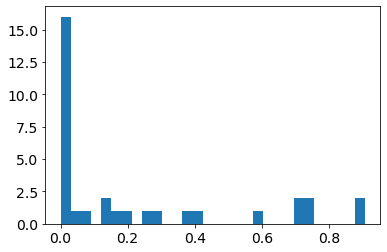

In [150]:
#Construct a dataframe with designation and mean radial velocities
df_mean = df_RVs.groupby('designation').mean('radial_velocity').reset_index()
Mean = df_mean['radial_velocity']

#Calculate the chi2 for each radial velocity
result = []
n_desig = df_mean['designation'].to_list() #number of designations (stars)
for i in range(len(n_desig)):
	desig = df_mean['designation'][i]
	print(desig)
	df_desig = df_RVs[df_RVs['designation'] == desig]
	n_obs = len(df_desig['designation'].tolist())
	mean = Mean.iloc[i]
	print(mean)
	f_exp = mean
	f_obs = np.zeros(1)
	f_err = np.zeros(1)
	for j in range(n_obs):
		RV = df_desig.iloc[j]['radial_velocity']
		RV_error = df_desig.iloc[j]['radial_velocity_error']
		f_obs = np.append(f_obs, RV)
		f_err = np.append(f_err, RV_error)  
		print(RV,RV_error)
	chi_square_statistic = np.sum(((f_obs[1:n_obs+1] - f_exp) / f_err[1:n_obs+1]) ** 2)
	degrees_of_freedom = n_obs - 1
	p = chi2.sf(chi_square_statistic, degrees_of_freedom)
	print(p)
	print('\n')
	result.append([desig, p])

df_chi2 = pd.DataFrame(result, columns=['designation', 'p-value'])
plt.hist(df_chi2['p-value'], bins=30)
candidates = df_chi2[df_chi2['p-value'] < 0.01]['designation'].tolist()

In [151]:
df_candidates_Gaia = df_Gaia[df_Gaia['designation'].isin(candidates)][['designation', 'ruwe']]
df_candidates = pd.merge(df_candidates_Gaia, df_chi2, on = 'designation')
# df_candidates.to_excel('/Users/mac/Desktop/table.xlsx')

In [152]:
df_candidates = df_candidates.sort_values(by="designation")
df_candidates

,designation,ruwe,p-value
6,J000045.08+062941.8,1.318706,1.013074e-51
4,J000556.86-012835.5,1.223657,6.372412e-08
5,J005251.44+104310.4,1.135965,0.000000e+00
7,J041912.65+563447.0,1.069349,5.923973e-10
2,J043813.67+320004.8,0.953592,8.147084e-03
8,J060632.03+125616.3,1.050003,0.000000e+00
0,J065401.91+752725.9,3.915628,3.574110e-18
10,J105757.26+543028.8,1.004966,0.000000e+00
9,J115258.27+344236.4,1.146493,1.600418e-05
3,J143837.34+561633.6,0.977247,7.585882e-66


In [153]:
df_final_candidates = df_candidates[(df_candidates['ruwe'] > 1.2) & (df_candidates['p-value'] < 0.05)]

In [ ]:
df_final_candidates

,designation,ruwe,p-value
6,J000045.08+062941.8,1.318706,1.013074e-51
4,J000556.86-012835.5,1.223657,6.372412e-08
0,J065401.91+752725.9,3.915628,3.574110e-18


In [179]:
candidates_desig = list(df_final_candidates["designation"])
candidates_RVs = df_RVs[df_RVs["designation"].isin(candidates_desig)].sort_values(by = 'designation')
candidates_RVs.to_csv("Data/RV_Gaia_LAMOST.csv")

In [157]:
Desig = ['J065401.91+752725.9', 'J065401.91+752725.9', 'J065401.91+752725.9', 'J065401.91+752725.9', 'J065401.91+752725.9', 'J000556.86-012835.5', 'J000556.86-012835.5', 'J000556.86-012835.5', 'J000556.86-012835.5', 'J000556.86-012835.5']
t = [60562.75,60704.66,60716.90,60728.85,60735.96, 60605.75,60664.58,60943.64,60992.53, 61172.93]
rv = [-337.5,-324.4,-344.45,-325.58, -331.7, -110.6,-113.8,-107.1,-109.8, -118.3]
err = [1.1,0.8,0.6,0.7,0.8,0.6,0.3,0.3,0.2, 0.4]
labels = ['APF', 'APF', 'APF', 'APF', 'APF', 'APF', 'MIKE', 'MIKE', 'MIKE', 'MIKE']

df_obs_new = pd.DataFrame({
	"designation":Desig, 
	"radial_velocity": rv,
	"radial_velocity_error":err,
	"epoch": t, 
	"label": labels
})
df_RVs_all = pd.concat([candidates_RVs, df_obs_new], ignore_index = True).sort_values(by = 'designation')
df_RVs_all.to_csv("RV_all.csv")

In [158]:
df_RVs_all

,designation,radial_velocity,radial_velocity_error,epoch,label
0,J000045.08+062941.8,-175.64000,1.150000,58794.00,LAMOST MRS
1,J000045.08+062941.8,-144.66833,2.244268,57382.84,Gaia
2,J000556.86-012835.5,-117.47000,1.010000,58452.00,LAMOST MRS
3,J000556.86-012835.5,-108.40317,1.502827,57382.84,Gaia
11,J000556.86-012835.5,-110.60000,0.600000,60605.75,APF
12,J000556.86-012835.5,-113.80000,0.300000,60664.58,MIKE
13,J000556.86-012835.5,-107.10000,0.300000,60943.64,MIKE
14,J000556.86-012835.5,-109.80000,0.200000,60992.53,MIKE
15,J000556.86-012835.5,-118.30000,0.400000,61172.93,MIKE
4,J065401.91+752725.9,-317.12000,1.190000,58437.00,LAMOST MRS


# Further study: Joker Sample

In [159]:
from thejoker import JokerPrior, TheJoker, RVData
from thejoker.plot import plot_rv_curves
import astropy.units as u

import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import exoplanet.units as xu

## J000556 Sampling

In [160]:
#INCLUDING MIKE OBSERVATIONS, APF, AND LAMOST MRS
t = [58452,59899,60605.75,60664.58,60943.64,60992.53, 61172.93]
rv = [-117.47,-116.64,-110.6,-113.8,-107.1,-109.8, -118.3] * u.km/u.s
err = [1.01,0.90,0.6,0.3,0.3,0.2,0.4] * u.km/u.s

data = RVData(t=t, rv=rv, rv_err=err)

#ORIGINAL JOKER PRIOR
#prior = JokerPrior.default(P_min=50*u.day, P_max=256*u.day,
#                           sigma_K0=50*u.km/u.s, sigma_v=25*u.km/u.s)

#CHANGE SYSTEMIC VELOCITY PRIOR TO A GAUSSIAN CENTERED AT 20 KM/S WITH SIGMA=25 KM/S
with pm.Model() as model:
#    v0 = xu.with_unit(pm.Normal('v0', 20., 25.),
#                     u.km/u.s)

	prior = JokerPrior.default(P_min=3*u.day, P_max=2000*u.day,
		sigma_K0=50*u.km/u.s,sigma_v=125*u.km/u.s)
#        pars={'v0': v0})

	
joker = TheJoker(prior)

prior_samples = prior.sample(size=1_000_000)
samples_J000556 = joker.rejection_sample(data, prior_samples)

In [161]:
samples_J000556 = samples_J000556[0]
samples_J000556["P"][0].value

390.83161902431436

## J065401 Sampling

In [162]:
#INCLUDING MIKE OBSERVATIONS, APF, AND LAMOST MRS

t = [57382.84,58437.00,60562.75,60704.66,60716.90,60728.85, 60735.96]
rv = [-335.4,-317.1,-337.5,-324.4,-344.45,-325.58, -331.7] * u.km/u.s
err = [2.3,1.2,1.1,0.8,0.6,0.7,0.8] * u.km/u.s

data = RVData(t=t, rv=rv, rv_err=err)

#ORIGINAL JOKER PRIOR
#prior = JokerPrior.default(P_min=50*u.day, P_max=256*u.day,
#                           sigma_K0=50*u.km/u.s, sigma_v=25*u.km/u.s)

#CHANGE SYSTEMIC VELOCITY PRIOR TO A GAUSSIAN CENTERED AT 20 KM/S WITH SIGMA=25 KM/S
with pm.Model() as model:
#    v0 = xu.with_unit(pm.Normal('v0', 20., 25.),
#                     u.km/u.s)

	prior = JokerPrior.default(P_min=3*u.day, P_max=100*u.day,
		sigma_K0=50*u.km/u.s,sigma_v=125*u.km/u.s)
#        pars={'v0': v0})


joker = TheJoker(prior)

prior_samples = prior.sample(size=10_000_000)
samples_J065401 = joker.rejection_sample(data, prior_samples)

In [163]:
samples_J065401['P'].value

array([ 4.51040302,  8.18986521, 10.32551879,  8.18997873,  8.19506896,
        3.68045182, 24.94665853, 10.32525068])

# Plotting the RVs

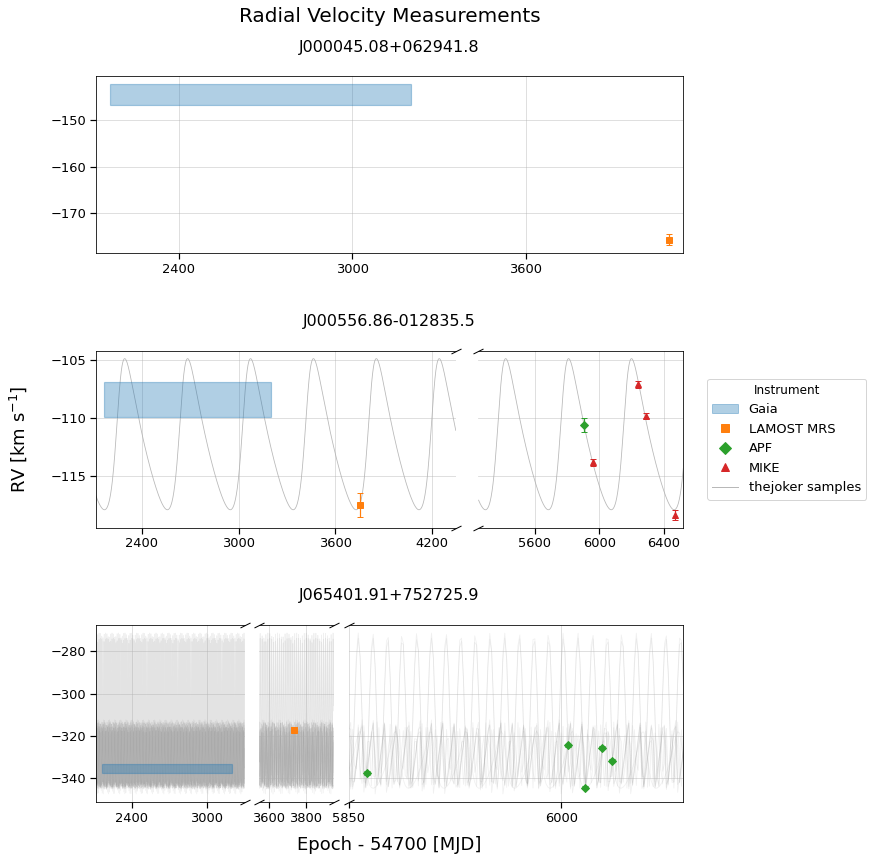

In [ ]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

OFFSET = 54700
XLIM_PAD = 50

GAIA_START = Time("2014-07-25").mjd - OFFSET
GAIA_END = Time("2017-05-28").mjd - OFFSET

designations_to_plot = [
    "J000045.08+062941.8",
    "J000556.86-012835.5",
    "J065401.91+752725.9",
]

samples_dict = {
    "J000556.86-012835.5": samples_J000556,
    "J065401.91+752725.9": samples_J065401,
}

label_styles = {
    "Gaia": dict(marker="o", color="tab:blue"),
    "LAMOST MRS": dict(marker="s", color="tab:orange"),
    "APF": dict(marker="D", color="tab:green"),
    "MIKE": dict(marker="^", color="tab:red"),
}

break_ranges = {
    "J000556.86-012835.5": [
        (59000 - OFFSET, 60000 - OFFSET)
    ],

    "J065401.91+752725.9": [
        (3250, 3600),
        (3900, 5900),
    ],
}

fig = plt.figure(figsize=(12, 12))

LEFT = 0.10
RIGHT = 0.78
panel_center_x = 0.5 * (LEFT + RIGHT)

outer_gs = fig.add_gridspec(
    3, 1,
    left=LEFT,
    right=RIGHT,
    bottom=0.08,
    top=0.92,
    hspace=0.55,
)

legend_handles = {}


def get_x_segments(xmin, xmax, breaks, pad=XLIM_PAD):
    breaks = sorted(breaks)
    segments = []
    start = xmin

    for b0, b1 in breaks:
        if start < b0:
            segments.append((start, b0))
        start = b1

    if start < xmax:
        segments.append((start, xmax))

    return [(a - pad, b + pad) for a, b in segments]


def add_break_marks(ax_left, ax_right, d=0.5):
    kwargs = dict(
        marker=[(-1, -d), (1, d)],
        markersize=10,
        linestyle="none",
        color="k",
        mec="k",
        mew=1,
        clip_on=False,
    )

    ax_left.plot([1], [0], transform=ax_left.transAxes, **kwargs)
    ax_left.plot([1], [1], transform=ax_left.transAxes, **kwargs)

    ax_right.plot([0], [0], transform=ax_right.transAxes, **kwargs)
    ax_right.plot([0], [1], transform=ax_right.transAxes, **kwargs)


def plot_one_star(desig, subplot_spec):

    df_star = (
        df_RVs_all[df_RVs_all["designation"] == desig]
        .sort_values("epoch")
        .copy()
    )

    x = df_star["epoch"].to_numpy() - OFFSET

    xmin = min(x.min(), GAIA_START)
    xmax = max(x.max(), GAIA_END)

    breaks = break_ranges.get(desig, [])

    if len(breaks) == 0:
        x_segments = [(xmin - XLIM_PAD, xmax + XLIM_PAD)]
    else:
        x_segments = get_x_segments(xmin, xmax, breaks, pad=XLIM_PAD)

    if desig == "J065401.91+752725.9":
        width_ratios = [2.0, 1.0, 4.5]
    else:
        width_ratios = [
            max(seg[1] - seg[0], 1)
            for seg in x_segments
        ]

    inner_gs = subplot_spec.subgridspec(
        1,
        len(x_segments),
        wspace=0.08,
        width_ratios=width_ratios,
    )

    axes = []

    for j, xlim in enumerate(x_segments):

        ax = fig.add_subplot(
            inner_gs[0, j],
            sharey=axes[0] if axes else None,
        )

        ax.set_xlim(*xlim)

        if desig == "J065401.91+752725.9":
            ax.xaxis.set_major_locator(MaxNLocator(nbins=2, integer=True))
        else:
            ax.xaxis.set_major_locator(MaxNLocator(nbins=4, integer=True))

        ax.tick_params(
            axis="both",
            which="major",
            labelsize=13,
            length=6,
            width=1.2,
        )

        axes.append(ax)

        if j > 0:
            ax.tick_params(left=False, labelleft=False)
            ax.spines["left"].set_visible(False)

        if j < len(x_segments) - 1:
            ax.spines["right"].set_visible(False)

    if desig in samples_dict:

        these_samples = samples_dict[desig]

        rng = np.random.default_rng(42)
        n_plot = min(100, len(these_samples))

        idx = rng.choice(
            len(these_samples),
            size=n_plot,
            replace=False,
        )

        chosen_samples = these_samples[idx]

        t_grid_shifted = np.linspace(
            xmin - XLIM_PAD,
            xmax + XLIM_PAD,
            3000,
        )

        t_grid = t_grid_shifted + OFFSET

        t_grid_time = Time(
            t_grid,
            format="mjd",
            scale="tcb",
        )

        model_rv = np.zeros((n_plot, len(t_grid)))

        for k in range(n_plot):
            orbit = chosen_samples.get_orbit(k)

            model_rv[k] = (
                orbit
                .radial_velocity(t_grid_time)
                .to(u.km / u.s)
                .value
            )

        for ax, xlim in zip(axes, x_segments):

            mask = (
                (t_grid_shifted >= xlim[0])
                &
                (t_grid_shifted <= xlim[1])
            )

            if desig == "J000556.86-012835.5":
                joker_alpha = 0.50
            elif desig == "J065401.91+752725.9":
                joker_alpha = 0.10
            else:
                joker_alpha = 0.10

            for k in range(n_plot):
                ax.plot(
                    t_grid_shifted[mask],
                    model_rv[k][mask],
                    color="0.45",
                    alpha=joker_alpha,
                    linewidth=0.8,
                    zorder=1,
                )
                
    for ax in axes:

        xlim = ax.get_xlim()

        for label, df_label in df_star.groupby("label"):

            style = label_styles.get(
                label,
                dict(marker="o", color="tab:gray"),
            )

            if label == "Gaia":

                for _, row in df_label.iterrows():

                    y_center = row["radial_velocity"]
                    yerr = row["radial_velocity_error"]

                    rect_x0 = max(GAIA_START, xlim[0])
                    rect_x1 = min(GAIA_END, xlim[1])

                    if rect_x1 <= rect_x0:
                        continue

                    rect = Rectangle(
                        (rect_x0, y_center - yerr),
                        rect_x1 - rect_x0,
                        2 * yerr,
                        facecolor=style["color"],
                        edgecolor=style["color"],
                        alpha=0.35,
                        linewidth=1.2,
                        zorder=4,
                    )

                    ax.add_patch(rect)

                if "Gaia" not in legend_handles:
                    legend_handles["Gaia"] = Patch(
                        facecolor=style["color"],
                        edgecolor=style["color"],
                        alpha=0.35,
                        label="Gaia",
                    )

                continue

            x_label = df_label["epoch"].to_numpy() - OFFSET

            visible = (
                (x_label >= xlim[0])
                &
                (x_label <= xlim[1])
            )

            df_plot = df_label[visible].copy()
            x_plot = df_plot["epoch"].to_numpy() - OFFSET

            if len(df_plot) == 0:
                continue

            ax.errorbar(
                x_plot,
                df_plot["radial_velocity"],
                yerr=df_plot["radial_velocity_error"],
                fmt=style["marker"],
                color=style["color"],
                ecolor=style["color"],
                markersize=6,
                capsize=3,
                linestyle="none",
                elinewidth=1.2,
                zorder=5,
            )

            if label not in legend_handles:
                legend_handles[label] = Line2D(
                    [0],
                    [0],
                    marker=style["marker"],
                    color=style["color"],
                    markerfacecolor=style["color"],
                    linestyle="none",
                    markersize=8,
                    label=label,
                )

        ax.grid(alpha=0.5)

    for j in range(len(axes) - 1):
        add_break_marks(axes[j], axes[j + 1])

    x0 = axes[0].get_position().x0
    x1 = axes[-1].get_position().x1
    y1 = axes[0].get_position().y1

    fig.text(
        0.5 * (x0 + x1),
        y1 + 0.025,
        desig,
        ha="center",
        va="bottom",
        fontsize=16,
    )

for i, desig in enumerate(designations_to_plot):
    plot_one_star(desig, outer_gs[i, 0])


legend_handles["TheJoker samples"] = Line2D(
    [0],
    [0],
    color="0.45",
    linewidth=1.0,
    alpha=0.5,
    label="thejoker samples",
)

fig.legend(
    handles=list(legend_handles.values()),
    loc="center left",
    bbox_to_anchor=(0.8, 0.5),
    frameon=True,
    fontsize=13,
    title="Instrument",
    title_fontsize=12,
)

fig.text(
    panel_center_x,
    1.0,
    "Radial Velocity Measurements",
    ha="center",
    va="top",
    fontsize=20,
)

fig.text(
    panel_center_x,
    0.02,
    f"Epoch - {OFFSET} [MJD]",
    ha="center",
    va="bottom",
    fontsize=18,
)

fig.text(
    0.01,
    0.5,
    r"RV [km s$^{-1}$]",
    ha="center",
    va="center",
    rotation="vertical",
    fontsize=18,
)

plt.savefig(
    "radial_velocity_panels_with_joker_curves.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()